# Predicting Data Science Job Salaries: Ridge Regression

The predictive task is to **predict data science job salaries based on job characteristics** such as experience level, job title, company size, and location.

This notebook builds, tunes, and evaluates the final Ridge Regression model.

Performance is assessed on a train-test split to measure generalization to unseen data.

## Data Loading

The dataset is reloaded here to ensure a clean and reproducible workflow. The data used is the same as in the EDA notebook.

In [1]:
# Upload dataset ZIP file to Google Colab
from google.colab import files
files.upload()
# upload the ZIP
!unzip archive.zip

Saving archive.zip to archive.zip
Archive:  archive.zip
  inflating: Data Science Jobs Salaries.csv  


In [2]:
# List extracted files
!ls

 archive.zip  'Data Science Jobs Salaries.csv'	 sample_data


## Importing Required Libraries

This section imports the Python libraries used for data manipulation, preprocessing, modeling, evaluation, and visualization throughout the analysis.

In [3]:
# Libraries for data handling
import pandas as pd
import numpy as np

# Libraries for model training and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

This section checks the first five rows to ensure that there is data.

In [4]:
df = pd.read_csv("Data Science Jobs Salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2021e,EN,FT,Data Science Consultant,54000,EUR,64369,DE,50,DE,L
1,2020,SE,FT,Data Scientist,60000,EUR,68428,GR,100,US,L
2,2021e,EX,FT,Head of Data Science,85000,USD,85000,RU,0,RU,M
3,2021e,EX,FT,Head of Data,230000,USD,230000,RU,50,RU,L
4,2021e,EN,FT,Machine Learning Engineer,125000,USD,125000,US,100,US,S


## Feature Selection

The target variable for this analysis is annual salary in USD. Predictor variables include job and company characteristics that are expected to influence compensation, such as experience level, employment type, job title, remote work ratio, company size, and company location.

In [5]:
# Define target variable
y = df["salary_in_usd"]

# Define feature matrix
X = df[
    [
        "experience_level",
        "employment_type",
        "job_title",
        "remote_ratio",
        "company_size",
        "company_location"
    ]
]

# Check dimensions
X.shape, y.shape

((245, 6), (245,))

## Data Preprocessing

Categorical features are one-hot encoded so that the models can interpret them numerically,
while numeric features are left unchanged.
This preprocessing is wrapped in a ColumnTransformer, which ensures consistent transformations
when used in model pipelines.

In [6]:
# Define categorical and numeric features
categorical_features = [
    "experience_level",
    "employment_type",
    "job_title",
    "company_size",
    "company_location"
]

numeric_features = ["remote_ratio"]

# Set up preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

## Train-Test Split

The dataset is split into training and testing sets to evaluate model performance on unseen data.
Eighty percent of the data is used for training and twenty percent is reserved for testing.
A fixed random seed is used to ensure reproducibility.

In [7]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Ridge Regression Model

A Ridge Regression model is used as the final predictive model due to its strong performance and regularization properties.

The model's performance is evaluated on the test set using RMSE and R² metrics.

In [8]:
ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0, random_state=42))
    ]
)

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

rmse_ridge, mae_ridge, r2_ridge

(np.float64(68909.7158050195), 40042.953260801725, 0.268931833580474)

## Predicted vs Actual Salaries

Plots help visualize model performance.

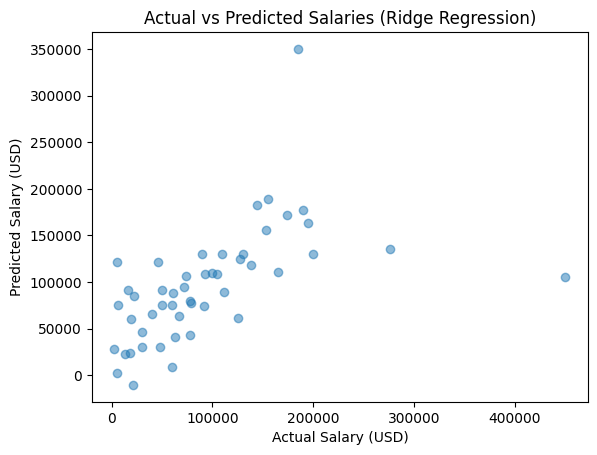

In [9]:
plt.figure()
plt.scatter(y_test, y_pred_ridge, alpha=0.5)
plt.xlabel("Actual Salary (USD)")
plt.ylabel("Predicted Salary (USD)")
plt.title("Actual vs Predicted Salaries (Ridge Regression)")
plt.show()

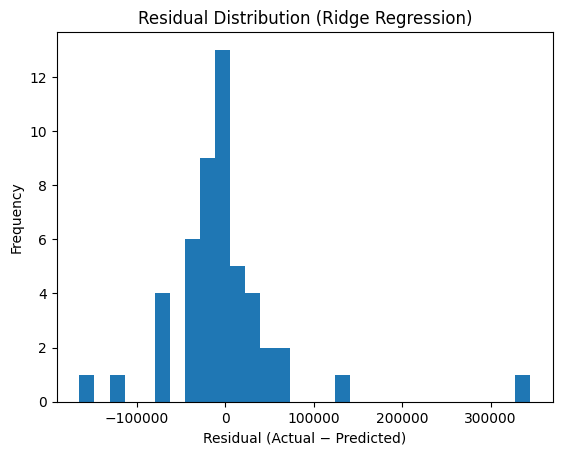

In [10]:
residuals = y_test - y_pred_ridge

plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Residual (Actual − Predicted)")
plt.ylabel("Frequency")
plt.title("Residual Distribution (Ridge Regression)")
plt.show()

In [11]:
feature_names = ridge_model.named_steps["preprocessor"].get_feature_names_out()

coefficients = ridge_model.named_steps["model"].coef_

feature_coefficient_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values(by="coefficient", ascending=False)

feature_coefficient_df.head(10)

,feature,coefficient
44,cat__job_title_Principal Data Engineer,167172.220557
32,cat__job_title_Financial Data Analyst,145036.810752
11,cat__job_title_Applied Machine Learning Scientist,137284.132300
1,cat__experience_level_EX,75488.420803
41,cat__job_title_Machine Learning Scientist,68857.460139
86,cat__company_location_US,65873.329042
38,cat__job_title_ML Engineer,59816.154276
71,cat__company_location_JP,52062.246905
45,cat__job_title_Principal Data Scientist,49100.454128
4,cat__employment_type_CT,45600.160626


## Interpretation of Results

### 1. Model Performance
**R² Score (~0.27)** and **MAE (\$40,000)**: The model explains roughly 27% of the variability in salaries, with an average error of around $40,000 (MAE). This indicates a weak to moderate fit, suggesting that salary is influenced by many other factors not captured in this dataset or requires more complex modeling.

For lower-paying roles, this mean absolute error is a substantial margin of error.

### 2. Key Influencers (Coefficients)
Top positive features driving salary increases include:
- **Job Title**: Specialized and senior roles like Principal Data Engineer (+\$167k), Financial Data Analyst (+\$145k), and Applied Machine Learning Scientist (+\$137k) have the highest premiums.
- **Experience**: Executive-level experience (`experience_level_EX`) adds approximately **\$75,000** to the baseline salary.
- **Location**: Working in the US (`company_location_US`) is associated with a salary increase of roughly **\$66,000** compared to the baseline.

### 3. Residual Analysis
- The histogram of residuals shows a distribution centered near zero but with a long tail.
- The scatter plot of Actual vs. Predicted values likely shows that the model **underpredicts** very high salaries (outliers), which is common in salary data where compensation can scale exponentially at the top end.

### 4. Future Work
To build a more precise predictor, future iterations should incorporate more granular data, such as specific technical skills (e.g., Python, AWS, Spark), years of experience as a continuous variable, and educational background.